Perform PCA and then lofistic Regression on loan_approval_dataset.csv file

In [179]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [180]:
df = pd.read_csv("loan_approval_dataset.csv")
print(df.info())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
None
Index(['loan_id', 'no_of_

In [195]:
numeric_cols = ['loan_id', 'no_of_dependents',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value']

In [196]:
X = df[numeric_cols]
y = df['loan_status']

In [197]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [198]:
model = LogisticRegression(max_iter = 500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = model.score(X_test, y_test)
print("Accuracy before PCA: ", score)

Accuracy before PCA:  0.8208430913348946


In [199]:
#Applying PCA
imputer = SimpleImputer(strategy = 'mean')
data_impute = imputer.fit_transform(df[numeric_cols])

new_df = pd.DataFrame(data_impute, columns = numeric_cols)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(new_df)


In [200]:
import numpy as np

In [201]:
for i in range(1, len(numeric_cols)+1):
    pca = PCA(n_components = i)
    data_pca  = pca.fit_transform(data_scaled)
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    if cumulative_variance[-1] >= 0.90:
        print("optimal number of components :", i)
        break

optimal number of components : 6


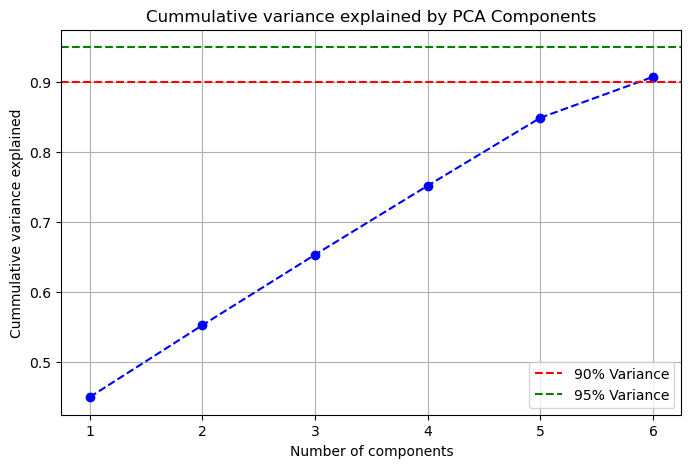

In [202]:
#Plot cummulative variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker = 'o', linestyle ='--', color ='b') 
plt.title("Cummulative variance explained by PCA Components")
plt.xlabel("Number of components")
plt.ylabel("Cummulative variance explained")
plt.axhline(y=0.9, color ='r', linestyle ='--', label = '90% Variance')
plt.axhline(y=0.95, color ='g', linestyle ='--', label = '95% Variance')
plt.legend()
plt.grid(True)
plt.show()

In [203]:
#original feature contribution
contribute = pd.DataFrame(pca.components_.T, columns = [f'PC{i+1}' for i in range(pca.n_components_)], index = numeric_cols)
print(contribute.round(3))

                            PC1    PC2    PC3    PC4    PC5    PC6
loan_id                   0.008  0.390  0.679 -0.353 -0.511 -0.008
no_of_dependents          0.003 -0.488  0.585 -0.268  0.590 -0.015
income_annum              0.459 -0.002 -0.003  0.003  0.005 -0.007
loan_amount               0.441  0.003 -0.010  0.014  0.001 -0.015
loan_term                 0.006  0.580 -0.277 -0.594  0.483 -0.021
cibil_score              -0.013  0.523  0.346  0.670  0.396  0.028
residential_assets_value  0.337  0.000  0.016 -0.017 -0.010  0.759
commercial_assets_value   0.340  0.010  0.022  0.038 -0.020 -0.648
luxury_assets_value       0.440 -0.009 -0.019  0.003  0.008 -0.004
bank_asset_value          0.415  0.003 -0.000  0.000  0.018 -0.055


In [204]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(data_pca, y, test_size = 0.3, random_state =42, stratify = y)
model.fit(X_train_red, y_train_red)
after_score = model.score(X_test_red, y_test_red)
print("Accuracy after pca : ",after_score)

Accuracy after pca :  0.9258391881342701
